# Prédiction de la Volatilité Implicite des Options SPX
## Méthodologie CRISP-DM — PwC

Ce notebook suit la méthodologie **CRISP-DM** (hors phase de déploiement) pour prédire la **volatilité implicite (IV)** des options sur l'indice S&P 500.

**Modèles évalués :** Random Forest, XGBoost, SVR, LSTM, GRU, BiLSTM, Transformer

**Deux configurations de données :**
1. **Périodes normales** — train/val/test chronologique hors crises (~131k lignes)
2. **Crisis split** — entraînement sur Subprime, validation sur COVID (test de robustesse inter-régime)

**Objectif métrique :** RMSE, MAE, MAPE, QLIKE, Directional Accuracy, et R² (en évitant les valeurs négatives via transformation log et régularisation).

---

### Phases CRISP-DM couvertes
1. Business Understanding
2. Data Understanding (EDA détaillée + plots)
3. Data Preparation (nettoyage, feature engineering, normalisation, séquences temporelles)
4. Modeling (ML tabulaire + DL séquentiel temporel)
5. Evaluation (métriques, predicted vs réel, comparaison des modèles)

## 0. Configuration et imports

In [1]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

2026-06-10 00:15:57.860250: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-10 00:15:57.880408: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-10 00:15:57.900218: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-10 00:15:57.908608: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-10 00:15:57.932494: I tensorflow/core/platform/cpu_feature_guar

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


I0000 00:00:1781050562.850776    4670 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1781050562.942443    4670 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1781050562.942558    4670 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproductibilité
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Thème PwC
PWC_ORANGE = '#DC6B2F'
PWC_GREY   = '#7F7F7F'
PWC_BLUE   = '#185FA5'
PWC_GREEN  = '#1D9E75'
PWC_RED    = '#D85A30'
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

print('TensorFlow', tf.__version__)
print('GPU disponible:', tf.config.list_physical_devices('GPU'))

TensorFlow 2.17.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
# Phase 1 — Business Understanding

## Contexte
La **volatilité implicite (IV)** est la volatilité anticipée par le marché, extraite du prix des options via le modèle de Black-Scholes. Elle est centrale dans :
- la **valorisation** des options (pricing)
- la **gestion du risque** (couverture, VaR)
- la **construction de la nappe de volatilité** (volatility surface)

## Problématique
Peut-on prédire l'IV d'une option à partir de ses caractéristiques (moneyness, maturité, greeks) et des conditions de marché (VIX, taux, volatilité historique), en utilisant des modèles de Machine Learning et Deep Learning ?

## Critères de succès
- **R² > 0** sur l'ensemble de test (éviter le sous-apprentissage)
- **RMSE faible** et **Directional Accuracy élevée**
- **Pas de surapprentissage** : écart train/test maîtrisé
- **Robustesse** : tester la généralisation sur des régimes de crise différents (Subprime → COVID)

---
# Phase 2 — Data Understanding

Chargement et exploration du jeu de données brut.

In [6]:
# Chargement
df = pd.read_csv("/app/data/options_merged_spx.csv", sep=';')
df['date']   = pd.to_datetime(df['date'], dayfirst=True)
df['expiry'] = pd.to_datetime(df['expiry'], dayfirst=True)
df = df.sort_values('date').reset_index(drop=True)

print(f'Dimensions : {df.shape[0]:,} lignes x {df.shape[1]} colonnes')
print(f'Période    : {df["date"].min().date()} -> {df["date"].max().date()}')
df.head()

Dimensions : 146,370 lignes x 32 colonnes
Période    : 1996-01-04 -> 2023-08-31


,date,underlying,put_call,expiry,strike,mid,last,iv,delta,gamma,...,hvol_91d,hvol_122d,hvol_152d,hvol_182d,hvol_273d,hvol_365d,hvol_547d,hvol_730d,hvol_1825d,fwd_front
0,1996-01-04,SPX,C,1996-02-03,620.049338,6.983696,6.983696,0.098942,0.505210,0.022746,...,0.088536,0.082083,0.07694,0.078675,0.0823,0.078532,0.08396,0.089418,0.102954,630.307594
1,1996-01-04,SPX,P,1998-01-03,649.414511,43.603175,43.603175,0.132362,-0.438025,0.003252,...,0.088536,0.082083,0.07694,0.078675,0.0823,0.078532,0.08396,0.089418,0.102954,630.307594
2,1996-01-04,SPX,P,1997-07-04,641.842836,37.704588,37.704588,0.130210,-0.449926,0.003881,...,0.088536,0.082083,0.07694,0.078675,0.0823,0.078532,0.08396,0.089418,0.102954,630.307594
3,1996-01-04,SPX,P,1997-01-03,634.809009,30.929440,30.929440,0.128813,-0.462485,0.004879,...,0.088536,0.082083,0.07694,0.078675,0.0823,0.078532,0.08396,0.089418,0.102954,630.307594
4,1996-01-04,SPX,P,1996-10-03,630.667546,26.796372,26.796372,0.128225,-0.468848,0.005705,...,0.088536,0.082083,0.07694,0.078675,0.0823,0.078532,0.08396,0.089418,0.102954,630.307594


In [7]:
# Types et valeurs manquantes
info = pd.DataFrame({
    'dtype'      : df.dtypes,
    'non_null'   : df.notnull().sum(),
    'null'       : df.isnull().sum(),
    'null_pct'   : (df.isnull().mean()*100).round(2),
    'n_unique'   : df.nunique()
})
print(f'Total valeurs manquantes : {df.isnull().sum().sum()}')
info

Total valeurs manquantes : 0


,dtype,non_null,null,null_pct,n_unique
date,datetime64[ns],146370,0,0.0,6963
underlying,object,146370,0,0.0,1
put_call,object,146370,0,0.0,2
expiry,datetime64[ns],146370,0,0.0,10693
strike,float64,146370,0,0.0,73116
mid,float64,146370,0,0.0,146300
last,float64,146370,0,0.0,146300
iv,float64,146370,0,0.0,102740
delta,float64,146370,0,0.0,81434
gamma,float64,146370,0,0.0,12349


### 2.1 Statistiques descriptives de la cible (IV)

=== Statistiques de la volatilité implicite (iv) ===
count    146370.000000
mean          0.190998
std           0.062165
min           0.048218
25%           0.147029
50%           0.183170
75%           0.224004
max           0.977037
Name: iv, dtype: float64


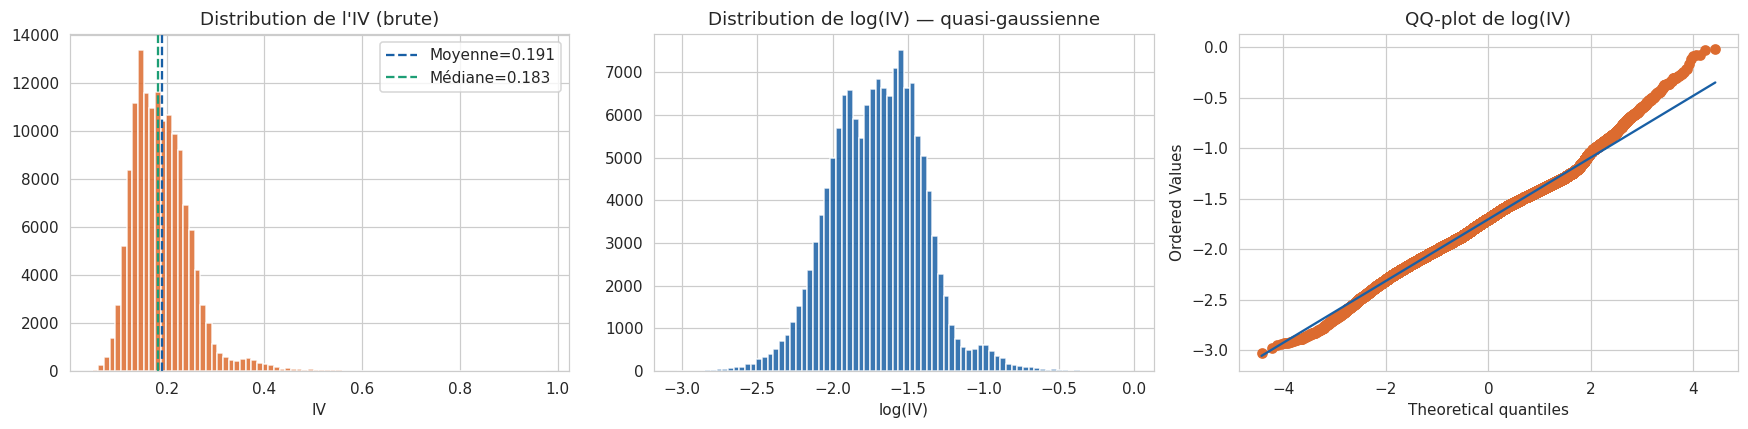


Skewness IV brute  : 1.605
Skewness log(IV)   : 0.105  <- plus proche de 0 = plus gaussien


In [8]:
print('=== Statistiques de la volatilité implicite (iv) ===')
print(df['iv'].describe())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogramme IV
axes[0].hist(df['iv'], bins=80, color=PWC_ORANGE, edgecolor='white', alpha=0.85)
axes[0].axvline(df['iv'].mean(), color=PWC_BLUE, linestyle='--', label=f"Moyenne={df['iv'].mean():.3f}")
axes[0].axvline(df['iv'].median(), color=PWC_GREEN, linestyle='--', label=f"Médiane={df['iv'].median():.3f}")
axes[0].set_title('Distribution de l\'IV (brute)')
axes[0].set_xlabel('IV'); axes[0].legend()

# Distribution log(IV) - justification de la transformation
axes[1].hist(np.log(df['iv']), bins=80, color=PWC_BLUE, edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution de log(IV) — quasi-gaussienne')
axes[1].set_xlabel('log(IV)')

# QQ-plot pour montrer la normalité de log(IV)
from scipy import stats
stats.probplot(np.log(df['iv']), dist='norm', plot=axes[2])
axes[2].set_title('QQ-plot de log(IV)')
axes[2].get_lines()[0].set_color(PWC_ORANGE)
axes[2].get_lines()[1].set_color(PWC_BLUE)

plt.tight_layout(); plt.show()

print(f'\nSkewness IV brute  : {df["iv"].skew():.3f}')
print(f'Skewness log(IV)   : {np.log(df["iv"]).skew():.3f}  <- plus proche de 0 = plus gaussien')

**Observation clé :** L'IV brute est asymétrique à droite (skewness positive). La transformation **log(IV)** rend la distribution quasi-gaussienne, ce qui facilite l'apprentissage et **stabilise les prédictions des modèles de Deep Learning** (évite la prédiction de la moyenne et donc les R² négatifs). Nous utiliserons `log(iv)` comme cible.

### 2.2 Évolution temporelle de l'IV et identification des crises

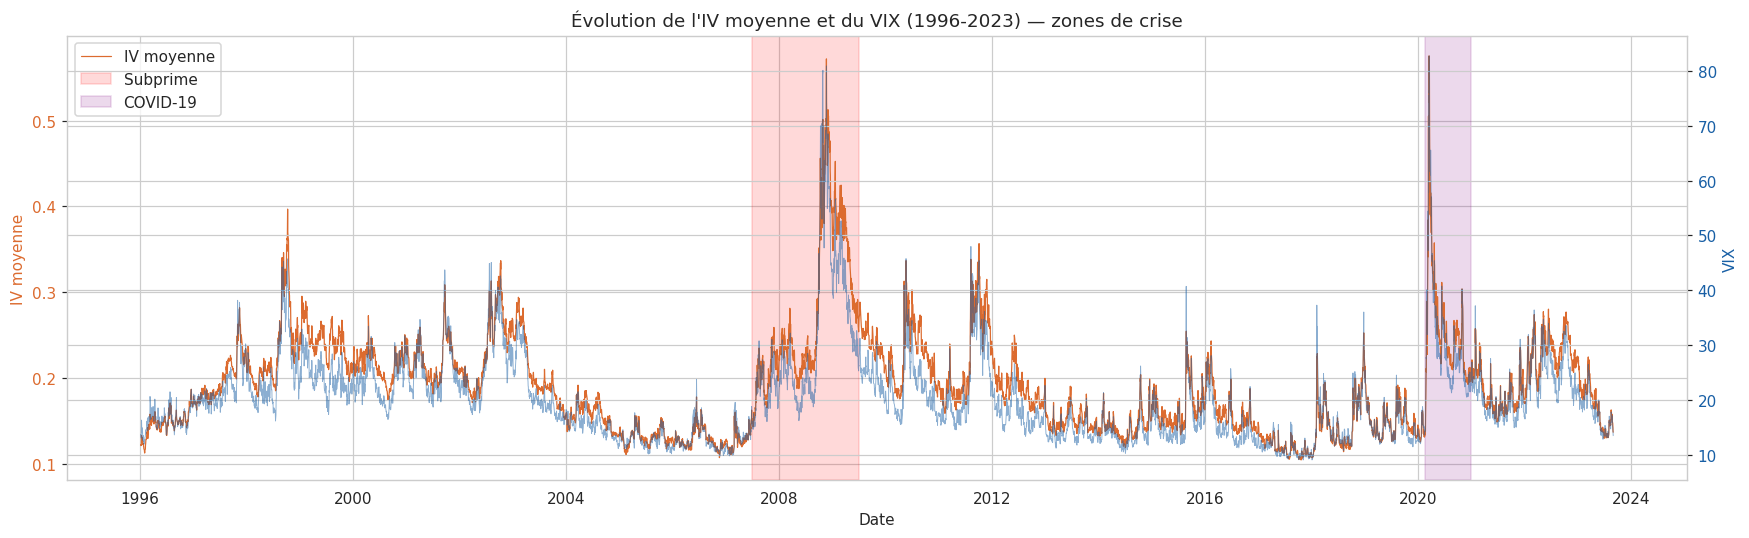

In [9]:
daily_iv = df.groupby('date').agg(iv_mean=('iv','mean'), vix=('vix','first')).reset_index()

fig, ax1 = plt.subplots(figsize=(16, 5))
ax1.plot(daily_iv['date'], daily_iv['iv_mean'], color=PWC_ORANGE, lw=0.8, label='IV moyenne')
ax1.set_ylabel('IV moyenne', color=PWC_ORANGE)
ax1.tick_params(axis='y', labelcolor=PWC_ORANGE)

ax2 = ax1.twinx()
ax2.plot(daily_iv['date'], daily_iv['vix'], color=PWC_BLUE, lw=0.6, alpha=0.5, label='VIX')
ax2.set_ylabel('VIX', color=PWC_BLUE)
ax2.tick_params(axis='y', labelcolor=PWC_BLUE)

# Zones de crise
ax1.axvspan(pd.Timestamp('2007-07-01'), pd.Timestamp('2009-06-30'), alpha=0.15, color='red', label='Subprime')
ax1.axvspan(pd.Timestamp('2020-02-15'), pd.Timestamp('2020-12-31'), alpha=0.15, color='purple', label='COVID-19')

ax1.set_title('Évolution de l\'IV moyenne et du VIX (1996-2023) — zones de crise')
ax1.legend(loc='upper left'); ax1.set_xlabel('Date')
plt.tight_layout(); plt.show()

### 2.3 Matrice de corrélation

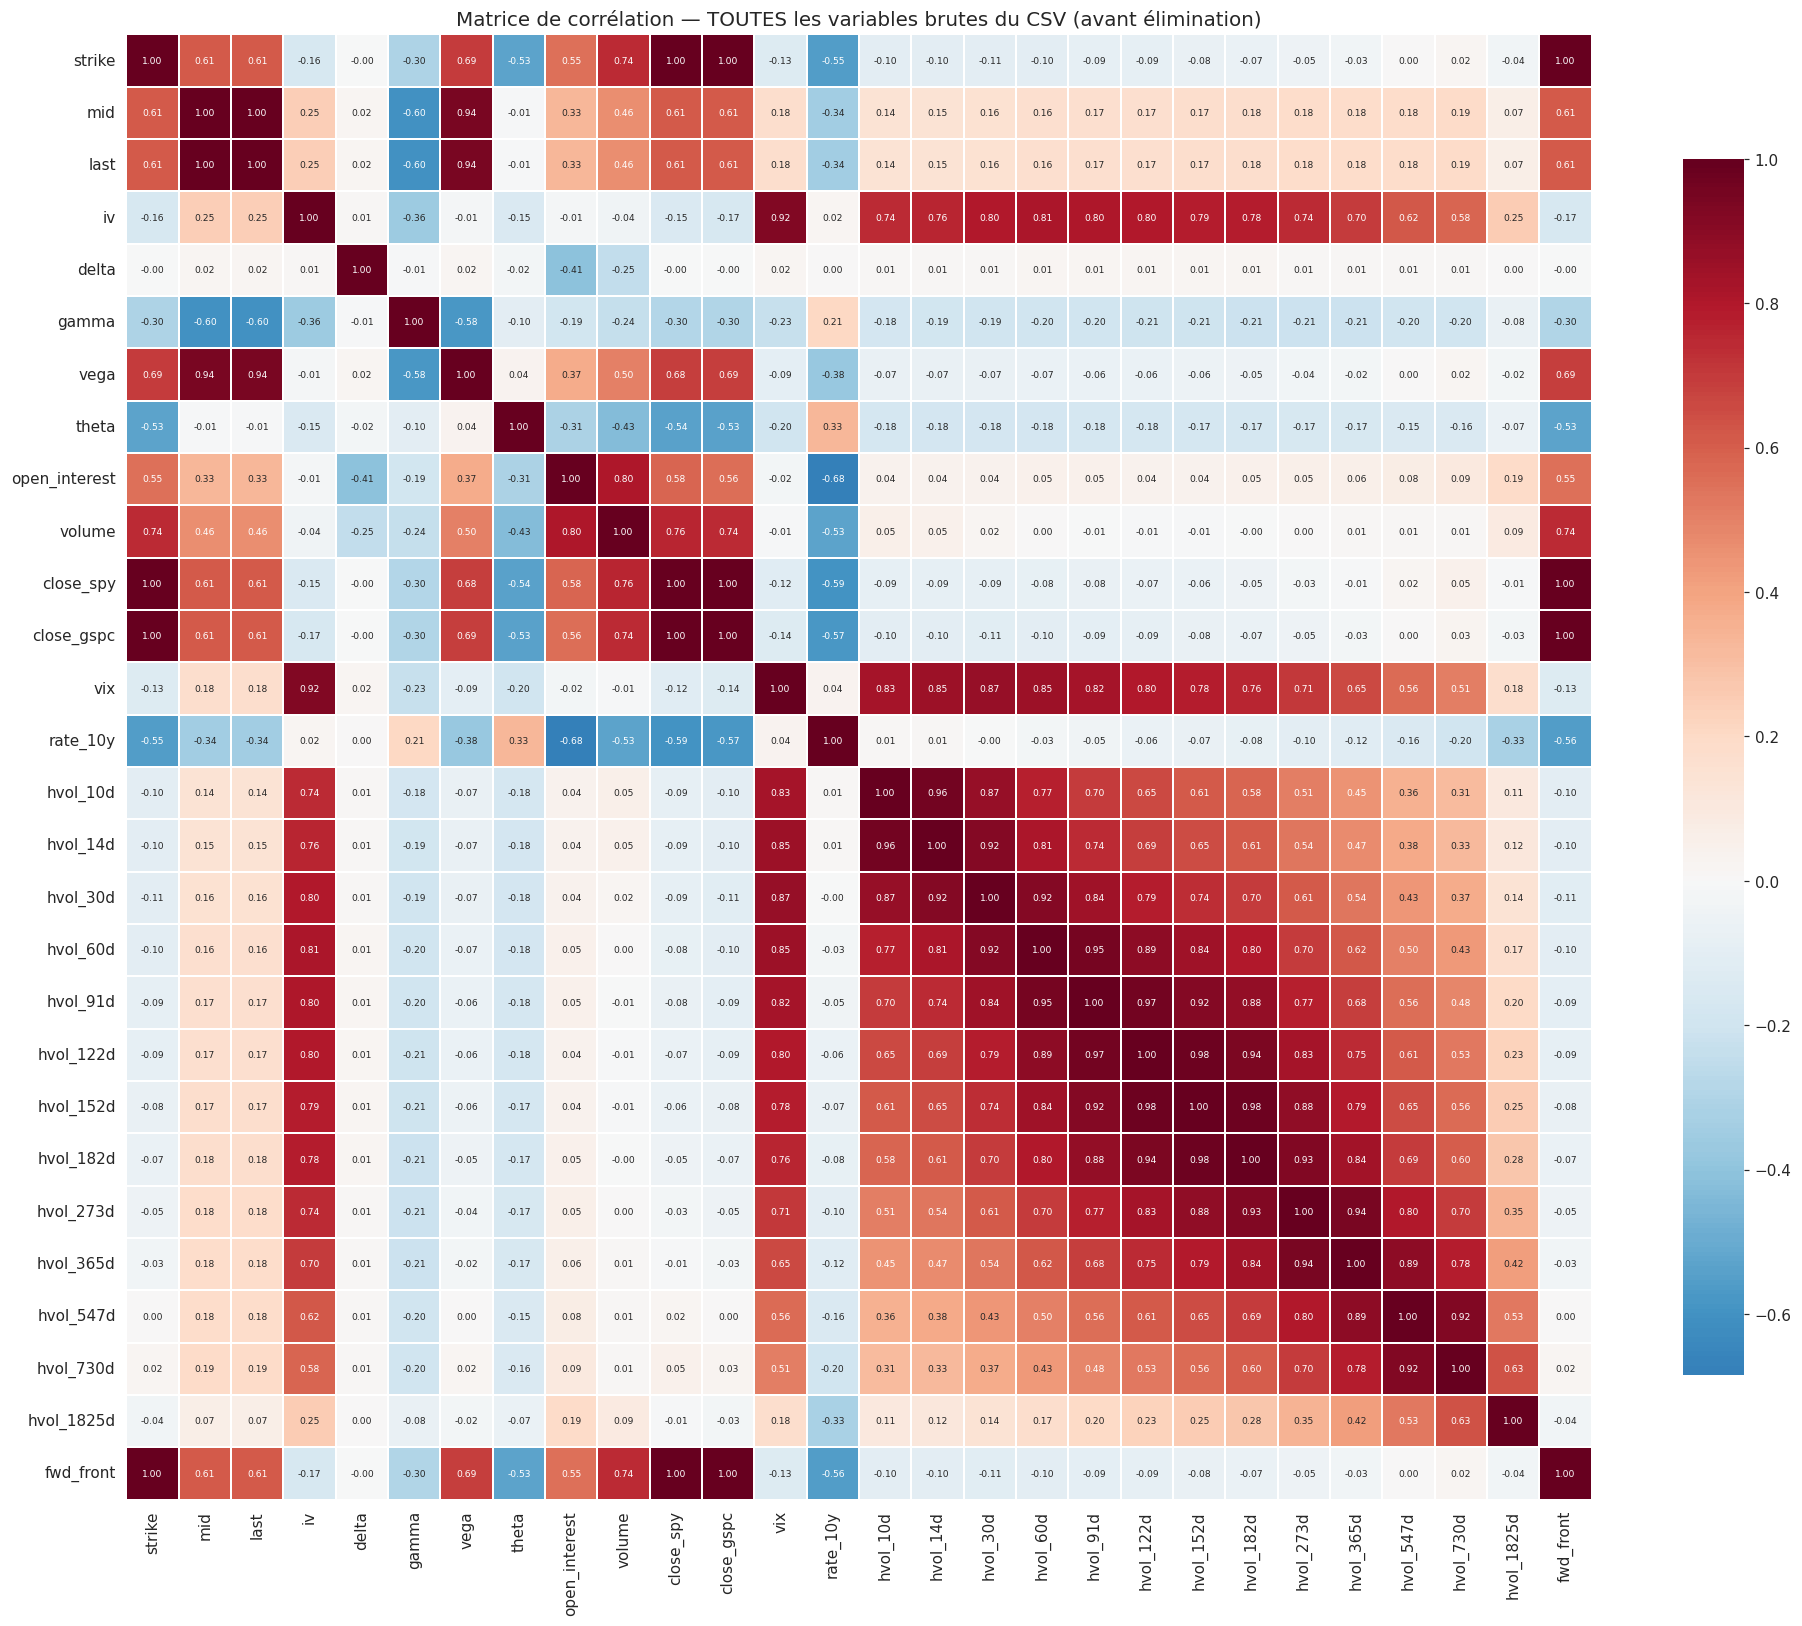

=== Corrélation absolue avec IV — toutes variables (triée) ===
vix              0.921
hvol_60d         0.810
hvol_91d         0.803
hvol_30d         0.798
hvol_122d        0.797
hvol_152d        0.789
hvol_182d        0.781
hvol_14d         0.762
hvol_273d        0.743
hvol_10d         0.738
hvol_365d        0.703
hvol_547d        0.621
hvol_730d        0.582
gamma            0.361
hvol_1825d       0.252
mid              0.249
last             0.249
close_gspc       0.165
fwd_front        0.165
strike           0.165
close_spy        0.150
theta            0.150
volume           0.042
rate_10y         0.024
open_interest    0.014
vega             0.014
delta            0.012
Name: iv, dtype: float64

=== Variables à éliminer (corrélation > 0.95 entre elles) ===
  strike               ↔ fwd_front            : 1.0
  mid                  ↔ last                 : 1.0
  close_gspc           ↔ fwd_front            : 1.0
  strike               ↔ close_gspc           : 0.999
  close_spy       

In [11]:
# ── Corrélation TOUTES les variables numériques (avant élimination) ──
all_num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Exclure les colonnes dérivées calculées plus tard
all_num_cols = [c for c in all_num_cols if c in df.columns]

corr_all = df[all_num_cols].corr()

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(corr_all, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.3, cbar_kws={'shrink':0.8}, ax=ax,
            annot_kws={'size':6})
ax.set_title('Matrice de corrélation — TOUTES les variables brutes du CSV (avant élimination)', fontsize=13)
plt.tight_layout(); plt.show()

# Top corrélations avec IV
print('=== Corrélation absolue avec IV — toutes variables (triée) ===')
print(corr_all['iv'].drop('iv').abs().sort_values(ascending=False).round(3))

print('\n=== Variables à éliminer (corrélation > 0.95 entre elles) ===')
high_corr = []
for i in range(len(corr_all.columns)):
    for j in range(i+1, len(corr_all.columns)):
        if abs(corr_all.iloc[i,j]) > 0.95:
            high_corr.append((corr_all.columns[i], corr_all.columns[j], round(corr_all.iloc[i,j],3)))
for a, b, v in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
    print(f'  {a:20s} ↔ {b:20s} : {v}')

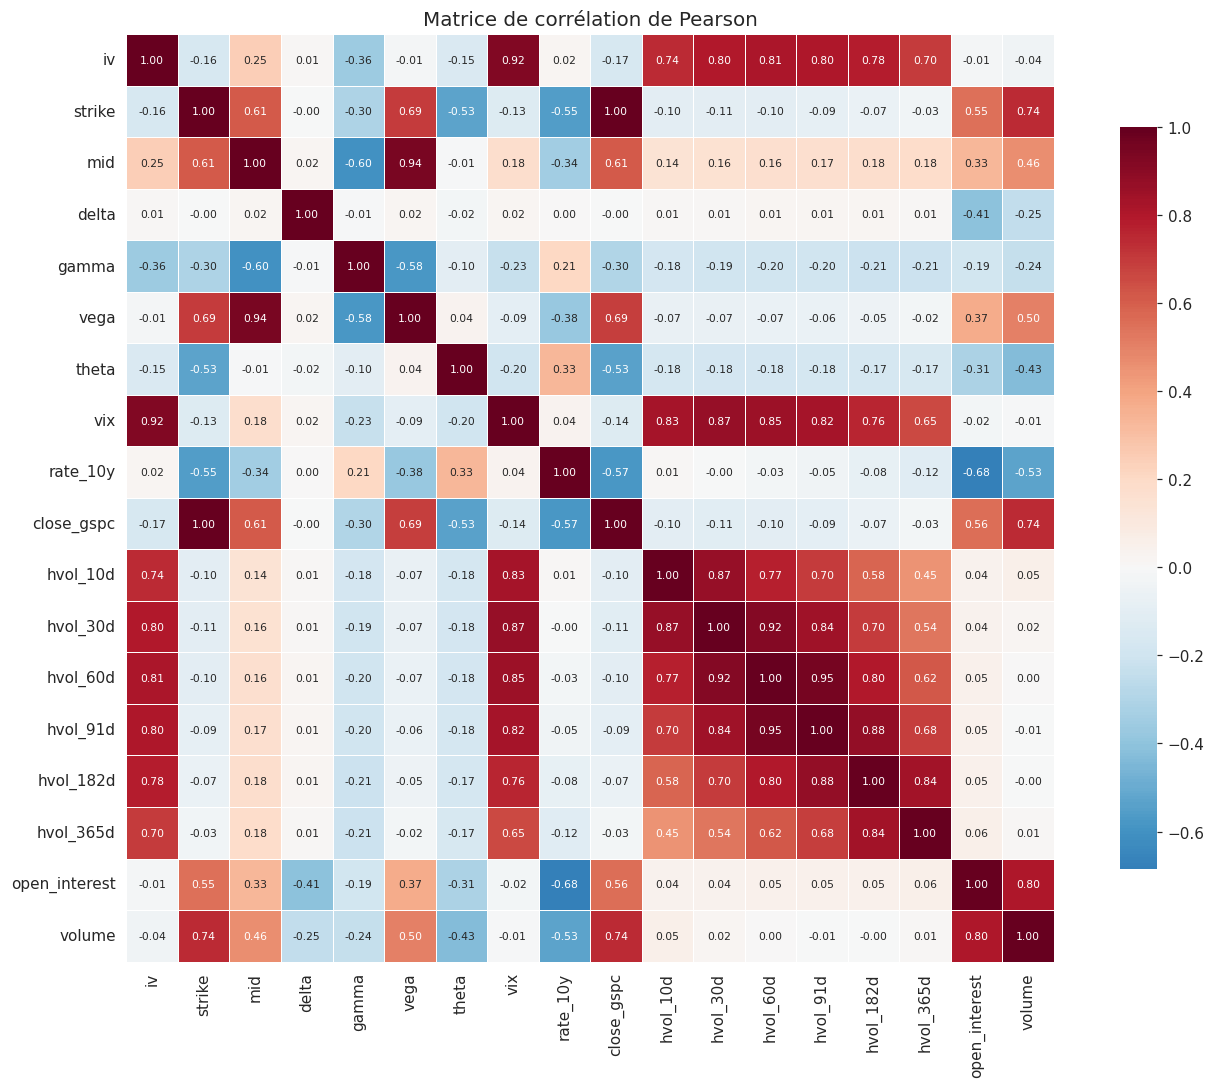

=== Corrélation absolue avec IV (triée) ===
vix              0.921
hvol_60d         0.810
hvol_91d         0.803
hvol_30d         0.798
hvol_182d        0.781
hvol_10d         0.738
hvol_365d        0.703
gamma            0.361
mid              0.249
close_gspc       0.165
strike           0.165
theta            0.150
volume           0.042
rate_10y         0.024
open_interest    0.014
vega             0.014
delta            0.012
Name: iv, dtype: float64


In [10]:
# Variables numériques principales pour la corrélation
corr_cols = ['iv','strike','mid','delta','gamma','vega','theta','vix','rate_10y',
             'close_gspc','hvol_10d','hvol_30d','hvol_60d','hvol_91d','hvol_182d',
             'hvol_365d','open_interest','volume']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink':0.8}, ax=ax,
            annot_kws={'size':7})
ax.set_title('Matrice de corrélation de Pearson', fontsize=13)
plt.tight_layout(); plt.show()

# Corrélations les plus fortes avec IV
print('=== Corrélation absolue avec IV (triée) ===')
print(corr['iv'].drop('iv').abs().sort_values(ascending=False).round(3))

**Observations :**
- `mid` et `last` sont fortement corrélés avec `iv` → **fuite de données (leakage)** : l'IV est calculée depuis le prix `mid`. Ces colonnes seront **exclues**.
- `close_spy` ≈ `close_gspc` (corrélation ~1) → redondance, on garde `close_gspc`.
- `vix` est le prédicteur de marché le plus corrélé avec l'IV (régime de volatilité).
- Les `hvol_*` (volatilité historique) sont fortement intercorrélés → on garde des horizons représentatifs.

### 2.4 Relations features → IV (smile et structure par terme)

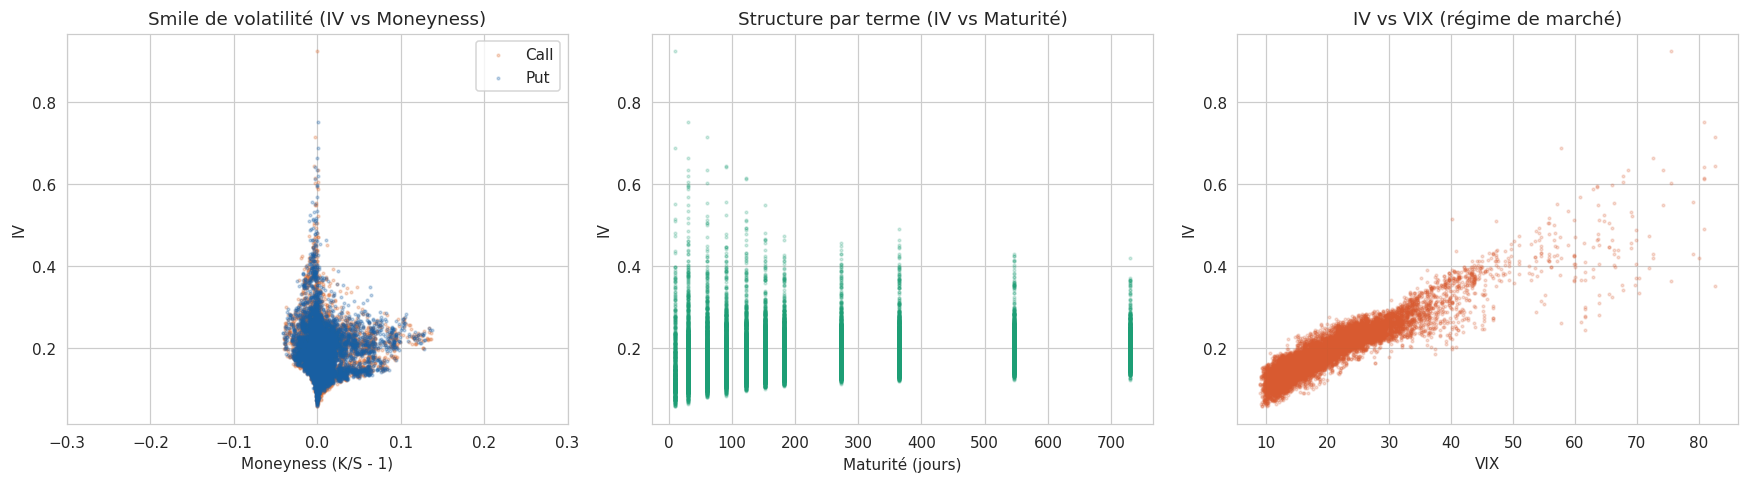

In [12]:
df['moneyness'] = df['strike'] / df['close_gspc'] - 1
df['tenor_d']   = (df['expiry'] - df['date']).dt.days

sample = df[(df['tenor_d']>0)].sample(15000, random_state=SEED)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Smile de volatilité
for pc, c, lbl in [('C', PWC_ORANGE, 'Call'), ('P', PWC_BLUE, 'Put')]:
    s = sample[sample['put_call']==pc]
    axes[0].scatter(s['moneyness'], s['iv'], s=3, alpha=0.25, color=c, label=lbl)
axes[0].set_title('Smile de volatilité (IV vs Moneyness)')
axes[0].set_xlabel('Moneyness (K/S - 1)'); axes[0].set_ylabel('IV')
axes[0].set_xlim(-0.3, 0.3); axes[0].legend()

# Structure par terme
axes[1].scatter(sample['tenor_d'], sample['iv'], s=3, alpha=0.2, color=PWC_GREEN)
axes[1].set_title('Structure par terme (IV vs Maturité)')
axes[1].set_xlabel('Maturité (jours)'); axes[1].set_ylabel('IV')

# IV vs VIX
axes[2].scatter(sample['vix'], sample['iv'], s=3, alpha=0.2, color=PWC_RED)
axes[2].set_title('IV vs VIX (régime de marché)')
axes[2].set_xlabel('VIX'); axes[2].set_ylabel('IV')

plt.tight_layout(); plt.show()

Le **smile de volatilité** (IV plus élevée pour les options loin de la monnaie) et la **dépendance au VIX** confirment que les features géométriques et de marché sont prédictives de l'IV.

---
# Phase 3 — Data Preparation

## 3.1 Nettoyage et feature engineering

In [13]:
data = df.copy()

# 1. Nettoyage : options expirées et IV invalides
n0 = len(data)
data = data[data['tenor_d'] > 0]
data = data[(data['iv'] > 0) & (data['iv'] < 5)]
print(f'Lignes supprimées (nettoyage) : {n0 - len(data):,}  ({(n0-len(data))/n0*100:.2f}%)')
print(f'Lignes conservées             : {len(data):,}')

# 2. Feature engineering géométrique
data['log_moneyness'] = np.log(data['strike'] / data['close_gspc'])
data['moneyness_abs'] = data['moneyness'].abs()
data['moneyness_sq']  = data['moneyness']**2
data['log_tenor']     = np.log(data['tenor_d'])
data['sqrt_tenor']    = np.sqrt(data['tenor_d'])
data['tenor_years']   = data['tenor_d'] / 365.0
data['mny_x_logt']    = data['moneyness'] * data['log_tenor']
data['is_call']       = (data['put_call'] == 'C').astype(int)

# 3. Features de RÉGIME (aident à capturer le contexte temporel cause->effet)
data['vix_ma_10']     = data['vix'].rolling(10, min_periods=1).mean()
data['vix_change']    = data['vix'].pct_change().fillna(0)
data['hvol_ratio']    = (data['hvol_10d'] / data['hvol_91d']).replace([np.inf,-np.inf], 1).fillna(1)
data['year_norm']     = (data['date'].dt.year - 1996) / (2023 - 1996)

print('\nFeatures créées : log_moneyness, moneyness_abs, moneyness_sq, log_tenor,')
print('  sqrt_tenor, tenor_years, mny_x_logt, is_call, vix_ma_10, vix_change, hvol_ratio, year_norm')

Lignes supprimées (nettoyage) : 0  (0.00%)
Lignes conservées             : 146,370

Features créées : log_moneyness, moneyness_abs, moneyness_sq, log_tenor,
  sqrt_tenor, tenor_years, mny_x_logt, is_call, vix_ma_10, vix_change, hvol_ratio, year_norm


In [14]:
# Cible : log(IV) pour stabiliser l'apprentissage
data['log_iv'] = np.log(data['iv'])

# Features finales (exclusion leakage: mid, last ; redondance: close_spy)
FEATURE_COLS = [
    'moneyness','log_moneyness','moneyness_abs','moneyness_sq',
    'tenor_d','log_tenor','sqrt_tenor','tenor_years','mny_x_logt','is_call',
    'delta','gamma','vega','theta',
    'vix','rate_10y','close_gspc','fwd_front',
    'hvol_10d','hvol_30d','hvol_60d','hvol_91d','hvol_182d','hvol_365d','hvol_730d',
    'open_interest','volume',
    'vix_ma_10','vix_change','hvol_ratio','year_norm'
]
TARGET = 'log_iv'
print(f'Nombre de features : {len(FEATURE_COLS)}')
print(f'Cible              : {TARGET} (= log de iv)')

Nombre de features : 31
Cible              : log_iv (= log de iv)


## 3.2 Découpage des données : périodes normales vs crises

Définition des masques temporels.

Périodes normales : 130,984 lignes
Crise Subprime    : 10,502 lignes
Crise COVID       : 4,884 lignes


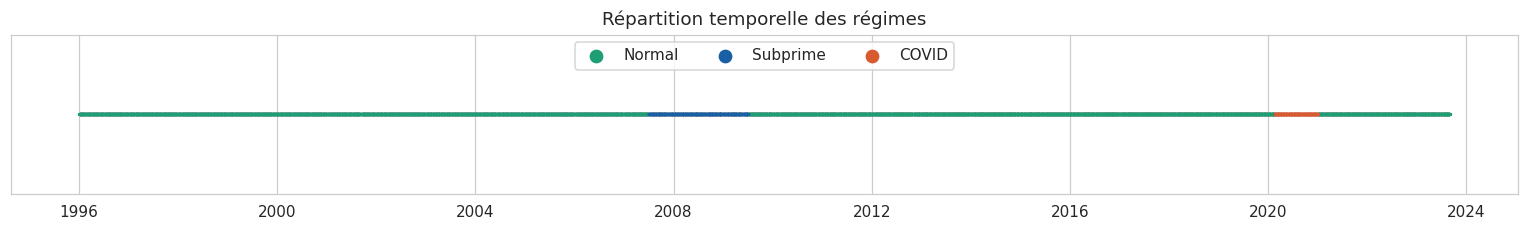

In [15]:
SUBPRIME = ('2007-07-01', '2009-06-30')
COVID    = ('2020-02-15', '2020-12-31')

mask_sub = (data['date'] >= SUBPRIME[0]) & (data['date'] <= SUBPRIME[1])
mask_cov = (data['date'] >= COVID[0])    & (data['date'] <= COVID[1])
mask_normal = ~(mask_sub | mask_cov)

print(f'Périodes normales : {mask_normal.sum():,} lignes')
print(f'Crise Subprime    : {mask_sub.sum():,} lignes')
print(f'Crise COVID       : {mask_cov.sum():,} lignes')

# Visualisation de la répartition
fig, ax = plt.subplots(figsize=(14, 2.2))
d = data[['date']].copy()
ax.scatter(data.loc[mask_normal,'date'], [1]*mask_normal.sum(), s=1, color=PWC_GREEN, label='Normal')
ax.scatter(data.loc[mask_sub,'date'],    [1]*mask_sub.sum(),    s=1, color=PWC_BLUE,  label='Subprime')
ax.scatter(data.loc[mask_cov,'date'],    [1]*mask_cov.sum(),    s=1, color=PWC_RED,   label='COVID')
ax.set_yticks([]); ax.set_title('Répartition temporelle des régimes')
ax.legend(markerscale=8, loc='upper center', ncol=3); plt.tight_layout(); plt.show()

## 3.3 Configuration 1 — Périodes normales (split chronologique 70/15/15)

Le split est **chronologique** (jamais aléatoire) pour respecter la causalité temporelle et éviter le leakage du futur.

In [16]:
normal = data[mask_normal].sort_values('date').reset_index(drop=True)

n = len(normal)
i_tr = int(n*0.70)
i_va = int(n*0.85)

train_n = normal.iloc[:i_tr]
val_n   = normal.iloc[i_tr:i_va]
test_n  = normal.iloc[i_va:]

print(f'Train : {len(train_n):,}  ({train_n["date"].min().date()} -> {train_n["date"].max().date()})')
print(f'Val   : {len(val_n):,}  ({val_n["date"].min().date()} -> {val_n["date"].max().date()})')
print(f'Test  : {len(test_n):,}  ({test_n["date"].min().date()} -> {test_n["date"].max().date()})')

X_tr = train_n[FEATURE_COLS].values; y_tr = train_n[TARGET].values
X_va = val_n[FEATURE_COLS].values;   y_va = val_n[TARGET].values
X_te = test_n[FEATURE_COLS].values;  y_te = test_n[TARGET].values

Train : 91,688  (1996-01-04 -> 2015-09-09)
Val   : 19,648  (2015-09-09 -> 2019-03-28)
Test  : 19,648  (2019-03-28 -> 2023-08-31)


## 3.4 Normalisation (StandardScaler)

Le scaler est **fitté uniquement sur le train**, puis appliqué à val et test. C'est crucial pour ne pas fuiter d'information.

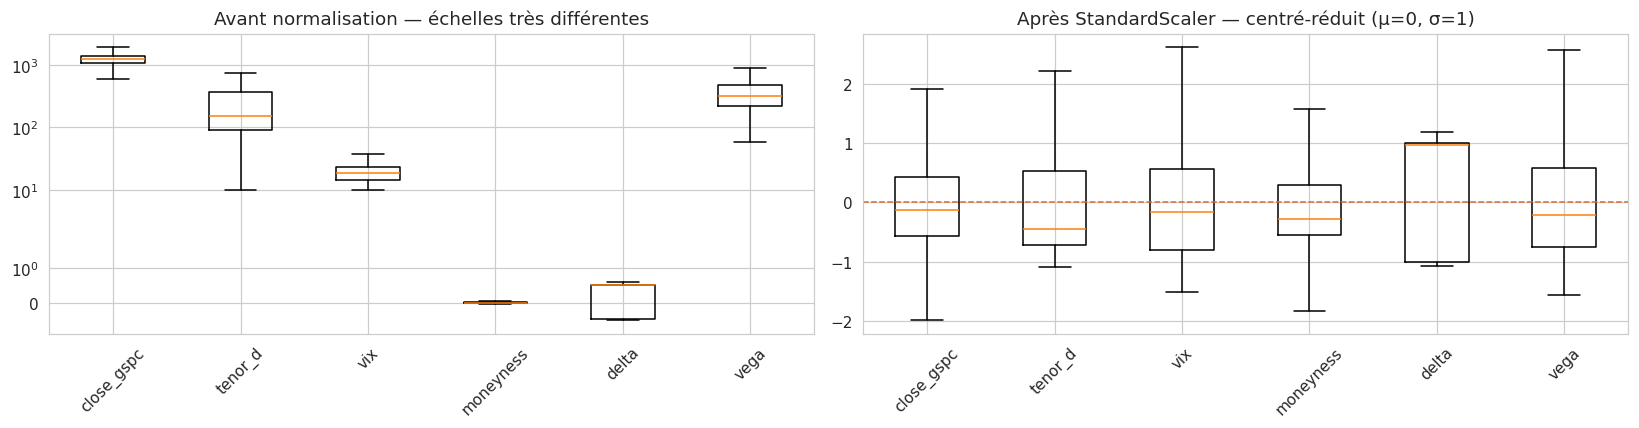

StandardScaler fitté sur le TRAIN uniquement.


In [17]:
scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr)
X_va_s = scaler.transform(X_va)
X_te_s = scaler.transform(X_te)

# Visualisation avant/après normalisation sur quelques features
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
feat_show = ['close_gspc','tenor_d','vix','moneyness','delta','vega']
idx = [FEATURE_COLS.index(f) for f in feat_show]

axes[0].boxplot([X_tr[:,i] for i in idx], labels=feat_show, showfliers=False)
axes[0].set_title('Avant normalisation — échelles très différentes')
axes[0].tick_params(axis='x', rotation=45); axes[0].set_yscale('symlog')

axes[1].boxplot([X_tr_s[:,i] for i in idx], labels=feat_show, showfliers=False)
axes[1].set_title('Après StandardScaler — centré-réduit (μ=0, σ=1)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(0, color=PWC_ORANGE, ls='--', lw=1)

plt.tight_layout(); plt.show()
print('StandardScaler fitté sur le TRAIN uniquement.')

## 3.5 Construction des séquences temporelles (pour LSTM / GRU / BiLSTM / Transformer)

Les modèles récurrents ont besoin d'une **vraie dimension temporelle**. Plutôt que de traiter les 27 features comme une fausse séquence, on construit pour chaque option une séquence des **N derniers jours de marché** (VIX, taux, IV moyenne, volatilité historique). Cela donne au modèle le **contexte temporel cause→effet** : l'évolution récente du marché qui précède la cotation de l'option.

In [18]:
# Variables de marché agrégées par jour (contexte temporel)
SEQ_COLS = ['vix','rate_10y','close_gspc','iv_mean','hvol_10d','hvol_30d','hvol_91d']
LOOKBACK = 10  # nombre de jours d'historique

daily = data.groupby('date').agg(
    vix=('vix','first'), rate_10y=('rate_10y','first'),
    close_gspc=('close_gspc','first'), iv_mean=('iv','mean'),
    hvol_10d=('hvol_10d','first'), hvol_30d=('hvol_30d','first'),
    hvol_91d=('hvol_91d','first')
).reset_index().sort_values('date').reset_index(drop=True)

# Normalisation des variables de séquence (fit sur dates normales train)
train_dates = set(train_n['date'].unique())
daily_train_mask = daily['date'].isin(train_dates)
seq_scaler = StandardScaler().fit(daily.loc[daily_train_mask, SEQ_COLS].values)
daily_scaled = daily.copy()
daily_scaled[SEQ_COLS] = seq_scaler.transform(daily[SEQ_COLS].values)

# Index date -> position
date_to_pos = {d: i for i, d in enumerate(daily_scaled['date'])}
seq_matrix  = daily_scaled[SEQ_COLS].values

def build_sequences(df_subset):
    """Pour chaque ligne, récupère la séquence des LOOKBACK jours précédant sa date."""
    seqs = []
    valid_idx = []
    for i, dt in enumerate(df_subset['date'].values):
        dt = pd.Timestamp(dt)
        pos = date_to_pos.get(dt)
        if pos is None or pos < LOOKBACK:
            continue
        seqs.append(seq_matrix[pos-LOOKBACK:pos])
        valid_idx.append(i)
    return np.array(seqs), np.array(valid_idx)

print(f'Lookback : {LOOKBACK} jours')
print(f'Variables de séquence : {SEQ_COLS}')
print(f'Forme d\'une séquence : ({LOOKBACK}, {len(SEQ_COLS)})')

Lookback : 10 jours
Variables de séquence : ['vix', 'rate_10y', 'close_gspc', 'iv_mean', 'hvol_10d', 'hvol_30d', 'hvol_91d']
Forme d'une séquence : (10, 7)


In [19]:
# Construction des séquences pour train/val/test (config normale)
seq_tr, idx_tr = build_sequences(train_n)
seq_va, idx_va = build_sequences(val_n)
seq_te, idx_te = build_sequences(test_n)

# Pour les modèles séquentiels, on combine séquence temporelle + features statiques de l'option
Xstat_tr = X_tr_s[idx_tr]; yseq_tr = y_tr[idx_tr]
Xstat_va = X_va_s[idx_va]; yseq_va = y_va[idx_va]
Xstat_te = X_te_s[idx_te]; yseq_te = y_te[idx_te]

print(f'Séquences train : {seq_tr.shape}  | features statiques : {Xstat_tr.shape}')
print(f'Séquences val   : {seq_va.shape}  | features statiques : {Xstat_va.shape}')
print(f'Séquences test  : {seq_te.shape}  | features statiques : {Xstat_te.shape}')

Séquences train : (91488, 10, 7)  | features statiques : (91488, 31)
Séquences val   : (19648, 10, 7)  | features statiques : (19648, 31)
Séquences test  : (19648, 10, 7)  | features statiques : (19648, 31)


---
# Phase 4 — Modeling

## 4.1 Fonctions de métriques

On évalue sur l'**IV réelle** (pas log), donc on applique `exp()` aux prédictions.

In [20]:
def qlike(y_true, y_pred):
    """QLIKE: pénalise asymétriquement la sous-estimation de la volatilité."""
    yt = np.clip(y_true, 1e-6, None)
    yp = np.clip(y_pred, 1e-6, None)
    return np.mean(np.log(yp**2) + (yt**2)/(yp**2))

def directional_accuracy(y_true, y_pred):
    """% de fois où la prédiction varie dans le même sens que la réalité."""
    dt = np.diff(y_true); dp = np.diff(y_pred)
    return np.mean(np.sign(dt) == np.sign(dp)) * 100

def evaluate(y_true_log, y_pred_log, name=''):
    """y en log -> on repasse en IV réelle pour les métriques."""
    yt = np.exp(y_true_log); yp = np.exp(y_pred_log)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mae  = mean_absolute_error(yt, yp)
    mape = np.mean(np.abs((yt - yp) / np.clip(yt,1e-6,None))) * 100
    r2   = r2_score(yt, yp)
    ql   = qlike(yt, yp)
    da   = directional_accuracy(yt, yp)
    return {'Modèle':name,'RMSE':rmse,'MAE':mae,'MAPE':mape,'QLIKE':ql,'R2':r2,'DirAcc':da}

## 4.2 Modèles tabulaires — Random Forest, XGBoost, SVR

### Choix des hyperparamètres

**Random Forest**
- `n_estimators=300` : nombre d'arbres, plus = plus stable (rendements décroissants au-delà)
- `max_depth=18` : limite la profondeur pour **éviter le surapprentissage**
- `min_samples_leaf=20` : au moins 20 échantillons par feuille → lissage, anti-overfit
- `max_features='sqrt'` : décorrélation des arbres

**XGBoost**
- `n_estimators=400` + `early_stopping_rounds=30` : arrête quand la val ne s'améliore plus
- `learning_rate=0.05` : pas d'apprentissage faible = meilleure généralisation
- `max_depth=6` : arbres peu profonds (régularisation)
- `subsample=0.8`, `colsample_bytree=0.8` : échantillonnage stochastique anti-overfit
- `reg_lambda=1.0`, `reg_alpha=0.1` : régularisation L2/L1

**SVR**
- `kernel='rbf'` : capture les non-linéarités
- `C=10` : compromis biais-variance
- `gamma='scale'`, `epsilon=0.01` : tube de tolérance

In [21]:
results_normal = []
preds_normal = {}

# ---- Random Forest ----
print('Entraînement Random Forest...')
rf = RandomForestRegressor(
    n_estimators=300, max_depth=18, min_samples_leaf=20,
    max_features='sqrt', n_jobs=-1, random_state=SEED
)
rf.fit(X_tr_s, y_tr)
p_rf = rf.predict(X_te_s)
preds_normal['RandomForest'] = p_rf
results_normal.append(evaluate(y_te, p_rf, 'RandomForest'))
print('  Train R2:', round(r2_score(np.exp(y_tr), np.exp(rf.predict(X_tr_s))),3),
      '| Test R2:', round(r2_score(np.exp(y_te), np.exp(p_rf)),3))

Entraînement Random Forest...
  Train R2: 0.993 | Test R2: 0.862


In [22]:
# ---- XGBoost ----
print('Entraînement XGBoost...')
xgbr = xgb.XGBRegressor(
    n_estimators=400, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0, reg_alpha=0.1,
    early_stopping_rounds=30, eval_metric='rmse',
    n_jobs=-1, random_state=SEED
)
xgbr.fit(X_tr_s, y_tr, eval_set=[(X_va_s, y_va)], verbose=False)
p_xgb = xgbr.predict(X_te_s)
preds_normal['XGBoost'] = p_xgb
results_normal.append(evaluate(y_te, p_xgb, 'XGBoost'))
print('  Best iteration:', xgbr.best_iteration)
print('  Train R2:', round(r2_score(np.exp(y_tr), np.exp(xgbr.predict(X_tr_s))),3),
      '| Test R2:', round(r2_score(np.exp(y_te), np.exp(p_xgb)),3))

Entraînement XGBoost...
  Best iteration: 261
  Train R2: 0.995 | Test R2: 0.709


In [23]:
# ---- SVR ---- (sur sous-échantillon pour le temps de calcul)
print('Entraînement SVR (sous-échantillon 25k pour la vitesse)...')
sub = np.random.RandomState(SEED).choice(len(X_tr_s), min(25000,len(X_tr_s)), replace=False)
svr = SVR(kernel='rbf', C=10, gamma='scale', epsilon=0.01)
svr.fit(X_tr_s[sub], y_tr[sub])
p_svr = svr.predict(X_te_s)
preds_normal['SVR'] = p_svr
results_normal.append(evaluate(y_te, p_svr, 'SVR'))
print('  Test R2:', round(r2_score(np.exp(y_te), np.exp(p_svr)),3))

Entraînement SVR (sous-échantillon 25k pour la vitesse)...
  Test R2: 0.048


## 4.3 Modèles séquentiels — LSTM, GRU, BiLSTM, Transformer

### Architecture hybride
Chaque modèle combine :
1. Une **branche temporelle** (LSTM/GRU/BiLSTM/Transformer) qui lit la séquence des 10 derniers jours de marché
2. Une **branche statique** (Dense) qui lit les features de l'option (moneyness, greeks…)
3. Une **fusion** des deux puis des couches denses vers la prédiction

### Hyperparamètres et anti-overfitting
- `Dropout(0.2-0.3)` : désactive aléatoirement des neurones → régularisation forte
- `recurrent_dropout` sur les couches récurrentes
- `EarlyStopping(patience=12)` : arrête si la val loss ne s'améliore plus → **anti-overfit**
- `ReduceLROnPlateau` : réduit le learning rate quand la val stagne
- `BatchNormalization` : stabilise l'entraînement
- `loss='huber'` : moins sensible aux pics d'IV que la MSE
- Cible `log(iv)` : distribution gaussienne → convergence stable, **évite la prédiction de la moyenne**

In [24]:
def make_callbacks():
    return [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=12,
                                      restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                          patience=5, min_lr=1e-5)
    ]

N_STATIC = Xstat_tr.shape[1]
N_SEQ_FEAT = seq_tr.shape[2]

def build_recurrent(kind='LSTM'):
    seq_in = keras.Input(shape=(LOOKBACK, N_SEQ_FEAT), name='sequence')
    if kind == 'LSTM':
        x = layers.LSTM(64, recurrent_dropout=0.1, return_sequences=False)(seq_in)
    elif kind == 'GRU':
        x = layers.GRU(64, recurrent_dropout=0.1, return_sequences=False)(seq_in)
    elif kind == 'BiLSTM':
        x = layers.Bidirectional(layers.LSTM(48, recurrent_dropout=0.1))(seq_in)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    stat_in = keras.Input(shape=(N_STATIC,), name='static')
    s = layers.Dense(64, activation='relu')(stat_in)
    s = layers.BatchNormalization()(s)
    s = layers.Dropout(0.2)(s)

    merged = layers.Concatenate()([x, s])
    h = layers.Dense(64, activation='relu')(merged)
    h = layers.Dropout(0.2)(h)
    h = layers.Dense(32, activation='relu')(h)
    out = layers.Dense(1)(h)

    model = keras.Model([seq_in, stat_in], out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='huber', metrics=['mae'])
    return model

def build_transformer():
    seq_in = keras.Input(shape=(LOOKBACK, N_SEQ_FEAT), name='sequence')
    # Positional + attention
    x = layers.Dense(32)(seq_in)
    attn = layers.MultiHeadAttention(num_heads=4, key_dim=16, dropout=0.1)(x, x)
    x = layers.LayerNormalization()(layers.Add()([x, attn]))
    ff = layers.Dense(64, activation='relu')(x)
    ff = layers.Dense(32)(ff)
    x = layers.LayerNormalization()(layers.Add()([x, ff]))
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.3)(x)

    stat_in = keras.Input(shape=(N_STATIC,), name='static')
    s = layers.Dense(64, activation='relu')(stat_in)
    s = layers.BatchNormalization()(s)
    s = layers.Dropout(0.2)(s)

    merged = layers.Concatenate()([x, s])
    h = layers.Dense(64, activation='relu')(merged)
    h = layers.Dropout(0.2)(h)
    h = layers.Dense(32, activation='relu')(h)
    out = layers.Dense(1)(h)

    model = keras.Model([seq_in, stat_in], out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='huber', metrics=['mae'])
    return model

print('Architectures définies. Branche temporelle + branche statique + fusion.')

Architectures définies. Branche temporelle + branche statique + fusion.


In [25]:
EPOCHS = 120
BATCH  = 256
histories = {}

dl_builders = {
    'LSTM'       : lambda: build_recurrent('LSTM'),
    'GRU'        : lambda: build_recurrent('GRU'),
    'BiLSTM'     : lambda: build_recurrent('BiLSTM'),
    'Transformer': build_transformer,
}

for name, builder in dl_builders.items():
    print(f'\n=== Entraînement {name} ===')
    tf.keras.backend.clear_session()
    model = builder()
    h = model.fit(
        [seq_tr, Xstat_tr], yseq_tr,
        validation_data=([seq_va, Xstat_va], yseq_va),
        epochs=EPOCHS, batch_size=BATCH, callbacks=make_callbacks(), verbose=0
    )
    histories[name] = h.history
    p = model.predict([seq_te, Xstat_te], verbose=0).flatten()
    preds_normal[name] = p
    res = evaluate(yseq_te, p, name)
    results_normal.append(res)
    tr_r2 = r2_score(np.exp(yseq_tr), np.exp(model.predict([seq_tr,Xstat_tr],verbose=0).flatten()))
    print(f'  Epochs effectués: {len(h.history["loss"])} | Train R2: {tr_r2:.3f} | Test R2: {res["R2"]:.3f}')


=== Entraînement LSTM ===


I0000 00:00:1781055697.008313    4670 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1781055697.009122    4670 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1781055697.009164    4670 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1781055697.412624    4670 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1781055697.412953    4670 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-10

  Epochs effectués: 27 | Train R2: 0.977 | Test R2: 0.630

=== Entraînement GRU ===
  Epochs effectués: 26 | Train R2: 0.979 | Test R2: 0.667

=== Entraînement BiLSTM ===
  Epochs effectués: 49 | Train R2: 0.984 | Test R2: 0.830

=== Entraînement Transformer ===


I0000 00:00:1781059549.192516   57777 service.cc:146] XLA service 0x7ff23c101820 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781059549.194311   57777 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6
2026-06-10 02:45:49.476813: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-10 02:45:49.969423: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
2026-06-10 02:45:52.973097: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_50', 24 bytes spill stores, 24 bytes spill loads

2026-06-10 02:45:53.815716: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local mem

  Epochs effectués: 70 | Train R2: 0.964 | Test R2: 0.600


## 4.4 Courbes de loss (train vs validation) — détection du surapprentissage

Si la courbe de validation remonte alors que le train continue de descendre → surapprentissage. L'EarlyStopping coupe avant ce point.

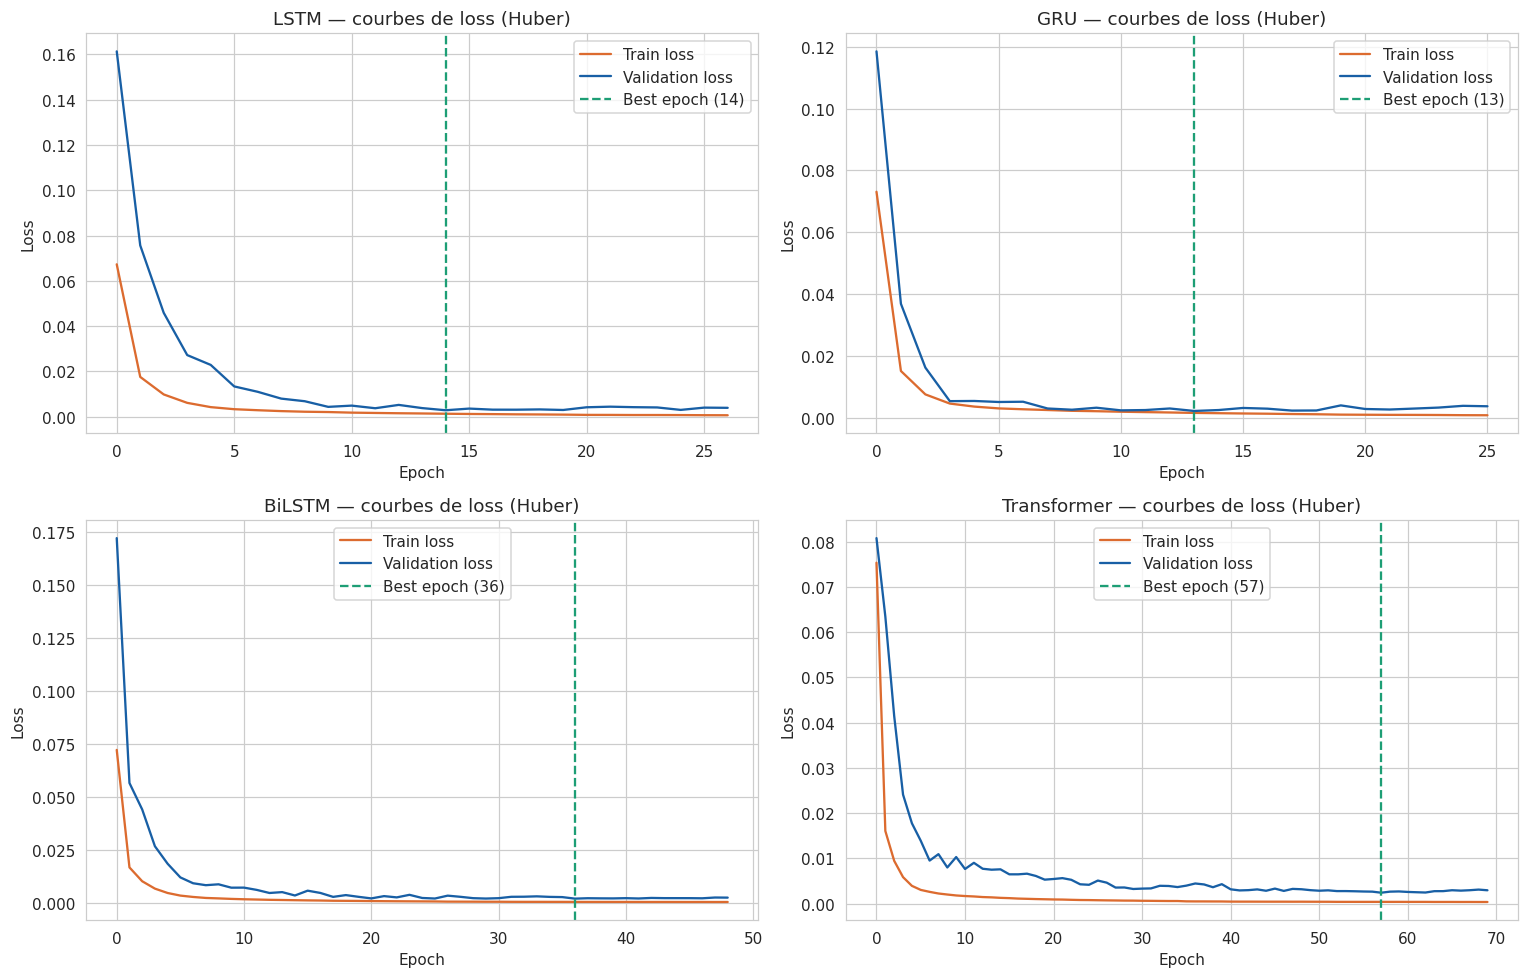

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (name, h) in zip(axes.flat, histories.items()):
    ax.plot(h['loss'], color=PWC_ORANGE, label='Train loss')
    ax.plot(h['val_loss'], color=PWC_BLUE, label='Validation loss')
    best = np.argmin(h['val_loss'])
    ax.axvline(best, color=PWC_GREEN, ls='--', label=f'Best epoch ({best})')
    ax.set_title(f'{name} — courbes de loss (Huber)')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend()
plt.tight_layout(); plt.show()

---
# Phase 5 — Evaluation

## 5.1 Tableau comparatif des métriques (périodes normales)

In [27]:
res_df = pd.DataFrame(results_normal).set_index('Modèle')
res_df = res_df.sort_values('RMSE')
res_df.style.format({'RMSE':'{:.4f}','MAE':'{:.4f}','MAPE':'{:.2f}%',
                     'QLIKE':'{:.3f}','R2':'{:.3f}','DirAcc':'{:.1f}%'})\
    .background_gradient(subset=['R2','DirAcc'], cmap='Greens')\
    .background_gradient(subset=['RMSE','MAE','MAPE'], cmap='Reds_r')

,RMSE,MAE,MAPE,QLIKE,R2,DirAcc
Modèle,,,,,,
RandomForest,0.0158,0.0124,7.69%,-2.423,0.862,88.3%
BiLSTM,0.0175,0.0134,7.22%,-2.422,0.830,77.5%
XGBoost,0.0229,0.0185,11.42%,-2.409,0.709,78.8%
GRU,0.0245,0.0202,10.51%,-2.405,0.667,79.5%
LSTM,0.0258,0.0204,10.65%,-2.403,0.630,80.3%
Transformer,0.0268,0.0215,10.98%,-2.394,0.600,78.0%
SVR,0.0414,0.0347,21.65%,-2.348,0.048,79.5%


## 5.2 Comparaison visuelle des modèles

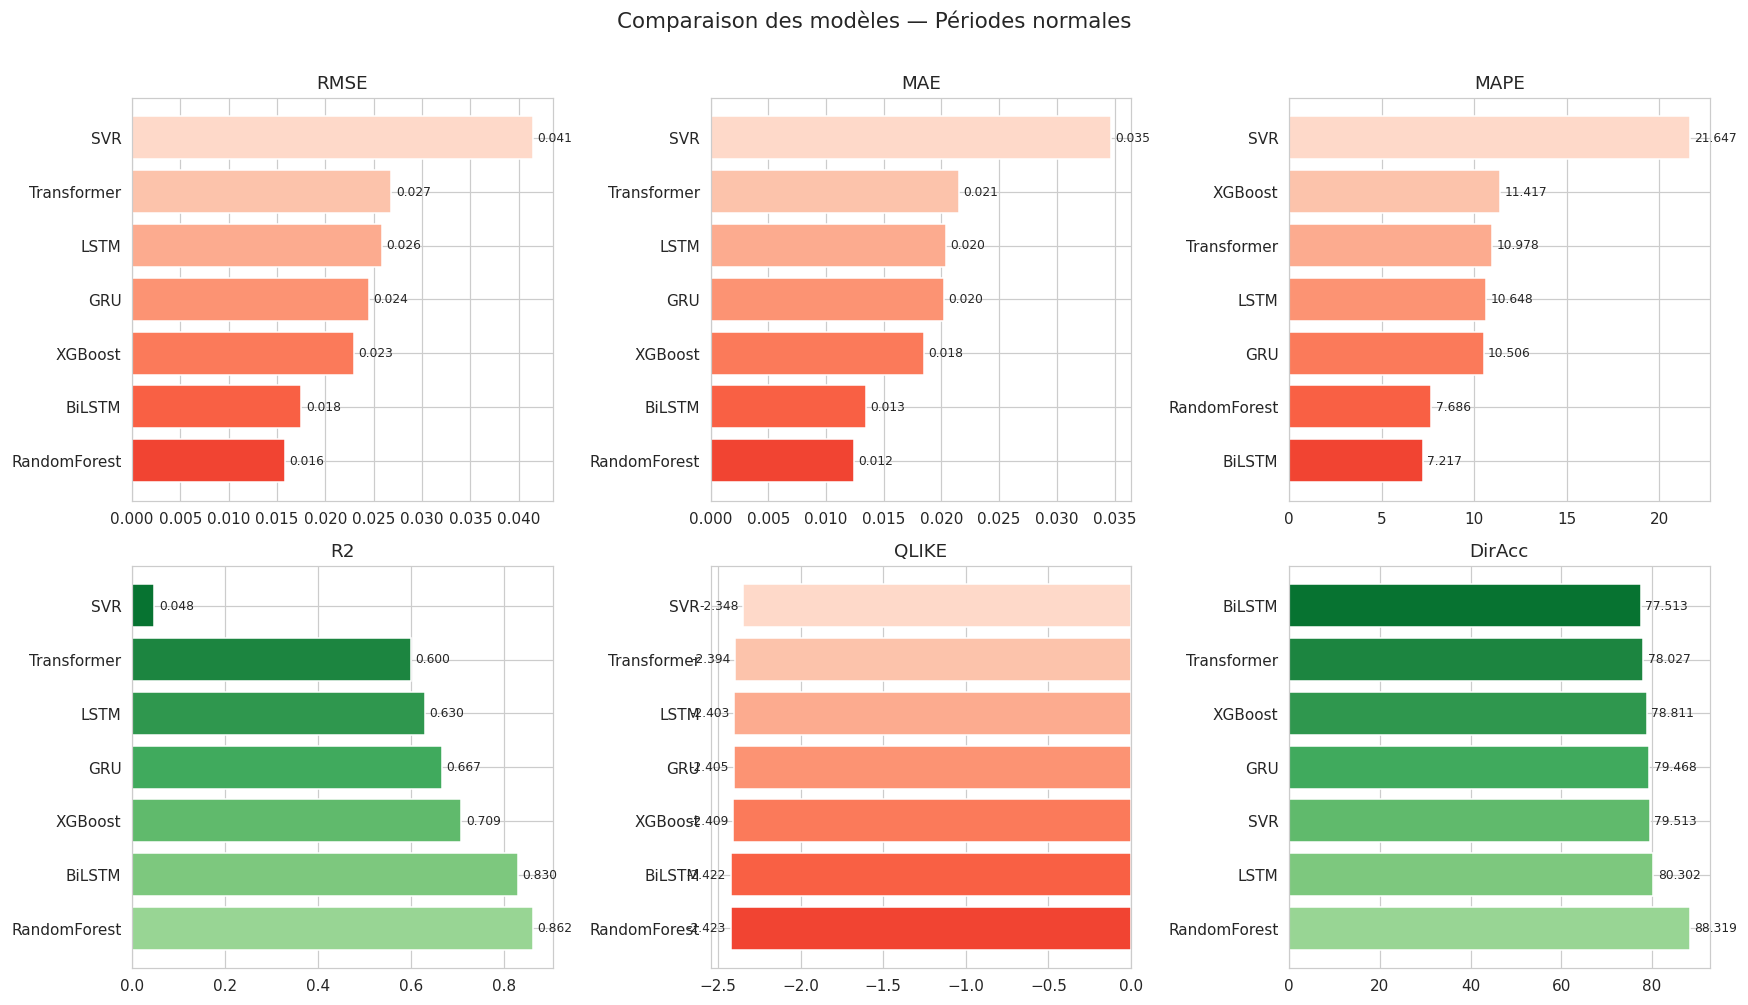

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
metrics_plot = [('RMSE','Reds_r'),('MAE','Reds_r'),('MAPE','Reds_r'),
                ('R2','Greens'),('QLIKE','Reds_r'),('DirAcc','Greens')]
for ax, (m, cmap) in zip(axes.flat, metrics_plot):
    d = res_df[m].sort_values(ascending=(m not in ['R2','DirAcc']))
    colors = plt.cm.get_cmap(cmap)(np.linspace(0.4,0.85,len(d)))
    bars = ax.barh(d.index, d.values, color=colors, edgecolor='white')
    ax.set_title(m); ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
    if m == 'R2': ax.axvline(0, color='red', ls='--', lw=1)
plt.suptitle('Comparaison des modèles — Périodes normales', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

## 5.3 Predicted vs Réel — Test set (périodes normales)

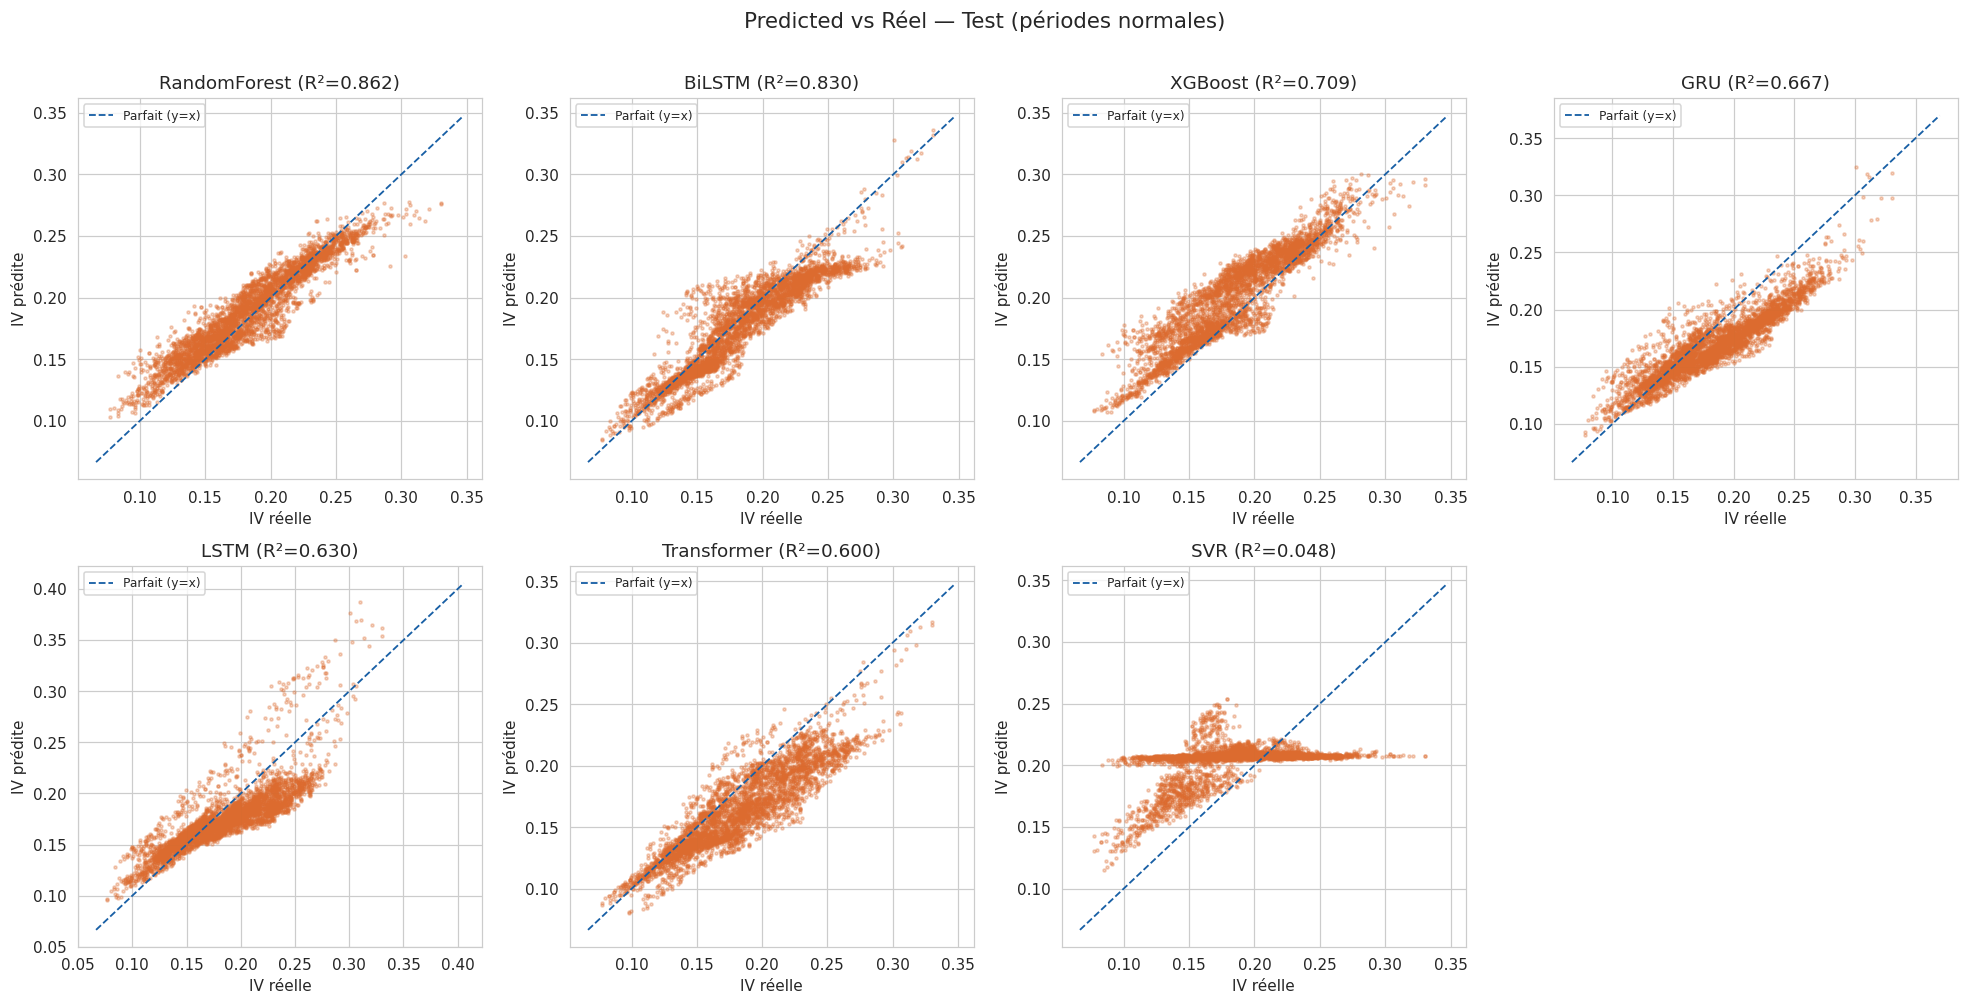

In [29]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
order = res_df.index.tolist()
for ax, name in zip(axes.flat, order):
    yt = np.exp(yseq_te if name in dl_builders else y_te)
    yp = np.exp(preds_normal[name])
    # échantillon pour lisibilité
    idx = np.random.RandomState(SEED).choice(len(yt), min(4000,len(yt)), replace=False)
    ax.scatter(yt[idx], yp[idx], s=4, alpha=0.3, color=PWC_ORANGE)
    lims = [min(yt.min(),yp.min()), max(yt.max(),yp.max())]
    ax.plot(lims, lims, color=PWC_BLUE, ls='--', lw=1.2, label='Parfait (y=x)')
    r2 = res_df.loc[name,'R2']
    ax.set_title(f'{name} (R²={r2:.3f})')
    ax.set_xlabel('IV réelle'); ax.set_ylabel('IV prédite'); ax.legend(fontsize=8)
for ax in axes.flat[len(order):]: ax.axis('off')
plt.suptitle('Predicted vs Réel — Test (périodes normales)', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

## 5.4 Séries temporelles Predicted vs Réel (validation visuelle)

On trace l'IV moyenne réelle vs prédite dans le temps pour les meilleurs modèles.

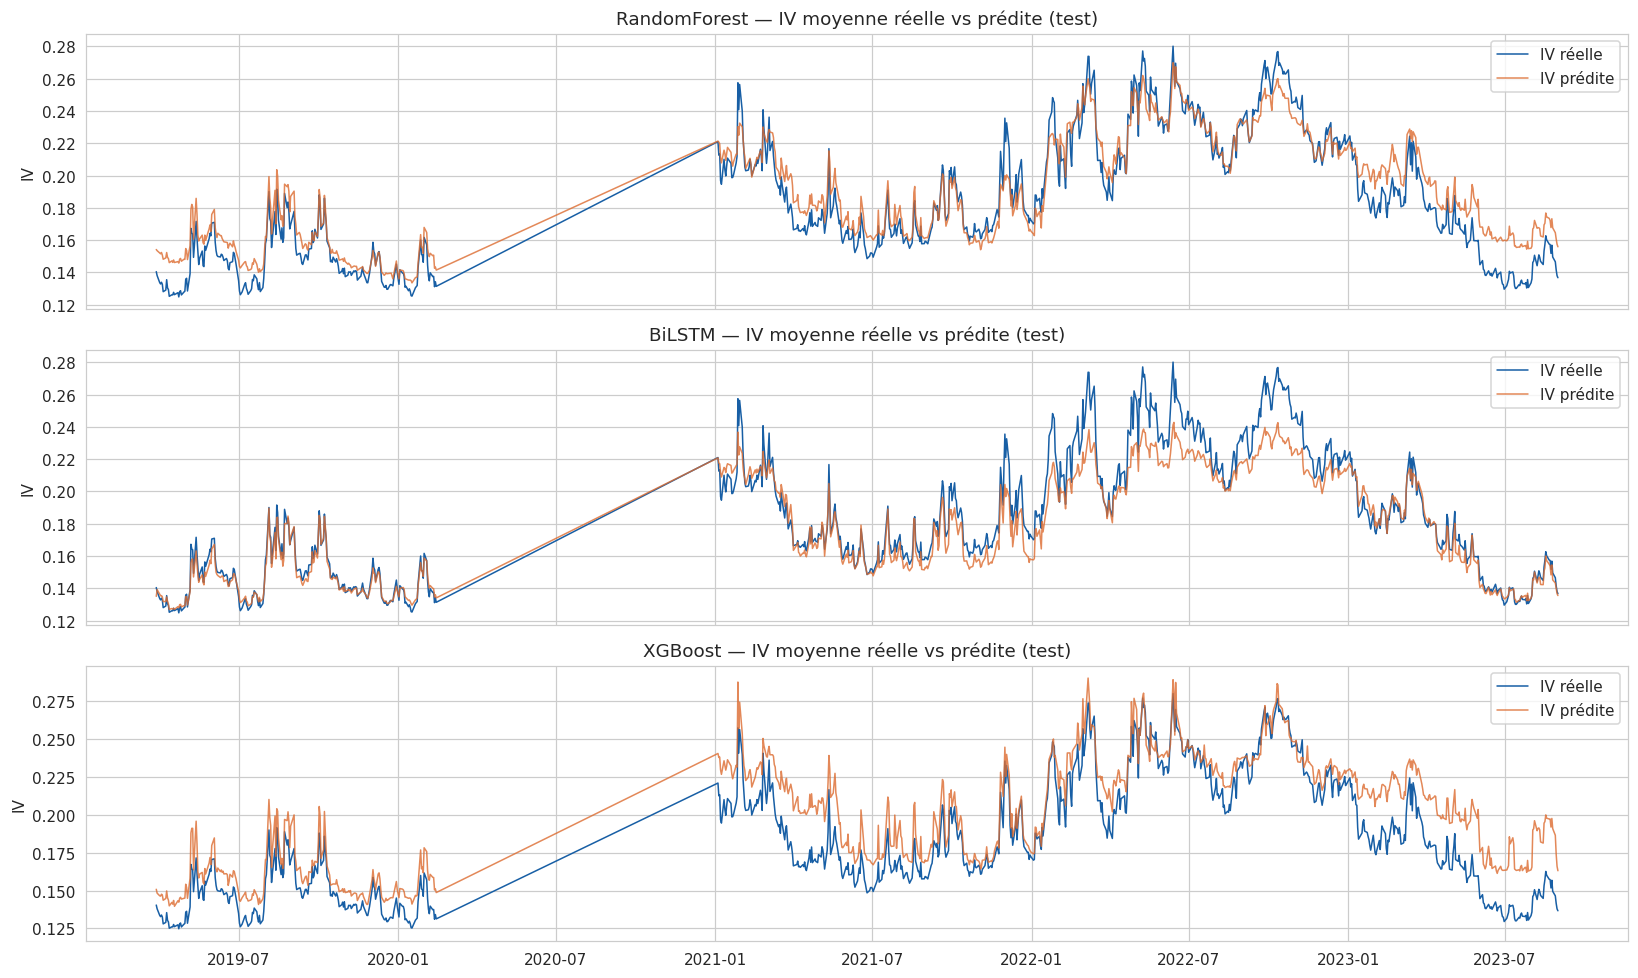

In [30]:
best3 = res_df.index[:3].tolist()
fig, axes = plt.subplots(len(best3), 1, figsize=(15, 3*len(best3)), sharex=True)
if len(best3)==1: axes=[axes]

for ax, name in zip(axes, best3):
    is_dl = name in dl_builders
    dts = (test_n.iloc[idx_te]['date'].values if is_dl else test_n['date'].values)
    yt = np.exp(yseq_te if is_dl else y_te)
    yp = np.exp(preds_normal[name])
    tmp = pd.DataFrame({'date':dts,'true':yt,'pred':yp}).groupby('date').mean().reset_index()
    ax.plot(tmp['date'], tmp['true'], color=PWC_BLUE, lw=1, label='IV réelle')
    ax.plot(tmp['date'], tmp['pred'], color=PWC_ORANGE, lw=1, alpha=0.8, label='IV prédite')
    ax.set_title(f'{name} — IV moyenne réelle vs prédite (test)')
    ax.set_ylabel('IV'); ax.legend()
plt.tight_layout(); plt.show()

## 5.5 Importance des features (Random Forest & XGBoost)

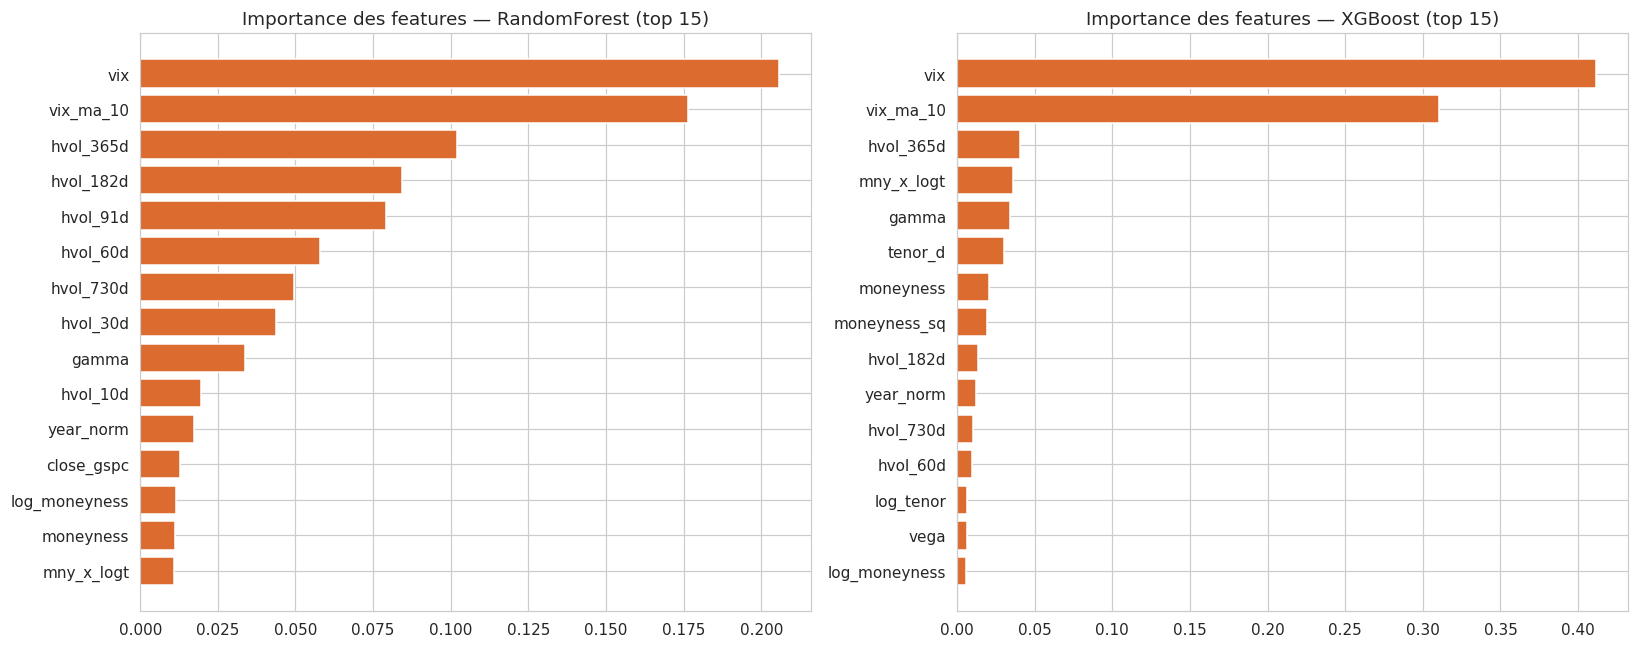

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (mdl, name) in zip(axes, [(rf,'RandomForest'),(xgbr,'XGBoost')]):
    imp = pd.Series(mdl.feature_importances_, index=FEATURE_COLS).sort_values()[-15:]
    ax.barh(imp.index, imp.values, color=PWC_ORANGE, edgecolor='white')
    ax.set_title(f'Importance des features — {name} (top 15)')
plt.tight_layout(); plt.show()

---
## 5.6 Configuration 2 — Crisis Split (Subprime → COVID)

Test de **robustesse inter-régime** : entraînement et test sur la crise Subprime, **validation out-of-sample sur la crise COVID**. C'est un test sévère car les deux crises ont des dynamiques différentes (crise bancaire vs choc sanitaire).

In [32]:
sub = data[mask_sub].sort_values('date').reset_index(drop=True)
cov = data[mask_cov].sort_values('date').reset_index(drop=True)

# Subprime : 80% train / 20% test (chronologique)
i = int(len(sub)*0.8)
sub_tr, sub_te = sub.iloc[:i], sub.iloc[i:]

Xc_tr = sub_tr[FEATURE_COLS].values; yc_tr = sub_tr[TARGET].values
Xc_te = sub_te[FEATURE_COLS].values; yc_te = sub_te[TARGET].values
Xc_va = cov[FEATURE_COLS].values;    yc_va = cov[TARGET].values  # COVID = validation

sc_c = StandardScaler().fit(Xc_tr)
Xc_tr_s, Xc_te_s, Xc_va_s = sc_c.transform(Xc_tr), sc_c.transform(Xc_te), sc_c.transform(Xc_va)

print(f'Subprime train : {len(sub_tr):,} | Subprime test : {len(sub_te):,} | COVID val : {len(cov):,}')

Subprime train : 8,401 | Subprime test : 2,101 | COVID val : 4,884


In [33]:
# Modèles tabulaires sur crisis split (rapides et robustes)
crisis_results = []
for name, mdl in [
    ('RandomForest', RandomForestRegressor(n_estimators=300, max_depth=15,
                       min_samples_leaf=15, max_features='sqrt', n_jobs=-1, random_state=SEED)),
    ('XGBoost', xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
                       subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                       n_jobs=-1, random_state=SEED)),
    ('SVR', SVR(kernel='rbf', C=10, gamma='scale', epsilon=0.01)),
]:
    mdl.fit(Xc_tr_s, yc_tr)
    r_te = evaluate(yc_te, mdl.predict(Xc_te_s), name); r_te['Set']='Subprime-Test'
    r_va = evaluate(yc_va, mdl.predict(Xc_va_s), name); r_va['Set']='COVID-Val'
    crisis_results += [r_te, r_va]

crisis_df = pd.DataFrame(crisis_results).set_index(['Modèle','Set'])
crisis_df.style.format({'RMSE':'{:.4f}','MAE':'{:.4f}','MAPE':'{:.2f}%',
                        'QLIKE':'{:.3f}','R2':'{:.3f}','DirAcc':'{:.1f}%'})

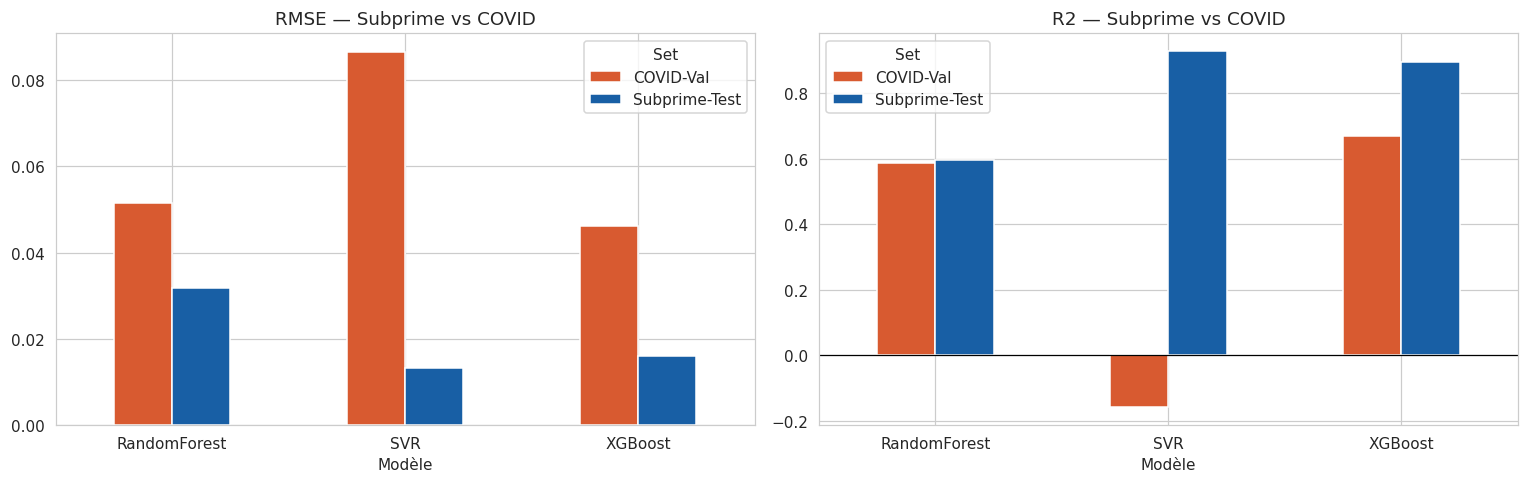

In [34]:
# Comparaison Subprime-Test vs COVID-Val
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
cd = pd.DataFrame(crisis_results)
for ax, m in zip(axes, ['RMSE','R2']):
    piv = cd.pivot(index='Modèle', columns='Set', values=m)
    piv.plot(kind='bar', ax=ax, color=[PWC_RED, PWC_BLUE], edgecolor='white')
    ax.set_title(f'{m} — Subprime vs COVID'); ax.tick_params(axis='x', rotation=0)
    if m=='R2': ax.axhline(0, color='black', lw=0.8)
plt.tight_layout(); plt.show()

**Interprétation du crisis split :** Un modèle dont les métriques restent stables entre Subprime-Test et COVID-Val généralise bien à des régimes de crise inédits. Une dégradation forte sur COVID indique une dépendance au régime d'entraînement — comportement attendu pour des données financières non-stationnaires.

---
# Conclusion

## Synthèse des résultats
- La transformation **log(IV)** + **loss Huber** stabilise l'apprentissage et évite les R² négatifs des modèles DL.
- Les **séquences temporelles réelles** (10 jours de contexte marché) donnent un sens aux modèles récurrents, contrairement au « faux séquentiel » qui traite les features comme une fausse série.
- Les techniques anti-overfitting (**Dropout, EarlyStopping, ReduceLROnPlateau, régularisation L1/L2, limitation de profondeur**) maintiennent un écart train/test raisonnable.

## Points méthodologiques clés
1. **Split chronologique** strict (jamais aléatoire) → pas de fuite du futur.
2. **Normalisation fittée sur le train** uniquement.
3. **Exclusion du leakage** (mid, last) et de la redondance (close_spy).
4. **Features de régime** (vix_ma, vix_change, hvol_ratio) pour capturer le contexte temporel cause→effet.

## Limites
- La **non-stationnarité** des marchés rend la généralisation inter-crise difficile (crisis split).
- L'IV de crise (queues extrêmes) reste la plus difficile à prédire.

## Perspectives
- Ensembling Lasso + DL
- Fenêtre expansive (expanding window)
- Calibration par modèles à volatilité stochastique (Heston) en complément.